# YOLO26s-cls — Anemia Classification Training

**Project** : AnedetApp — Phase 2 (Classification)  
**Model**   : `yolo26s-cls`  
**Classes** : `anemic` (0) · `non-anemic` (1) — alphabetical order, matches AnedetApp  
**Input**   : Pre-cropped conjunctiva patches from Roboflow dataset  
**Target**  : Export **TFLite FP16** (primary Android) + **ONNX FP32** (parity/debug)

---
| # | Section |
|---|---|
| 1 | Environment Setup |
| 2 | Dataset Download (Roboflow) |
| 3 | Dataset Inspection & Visualisation |
| 4 | Training YOLO26s-cls |
| 5 | Evaluation — Metrics, Confusion Matrix, Per-class Report |
| 6 | Export (TFLite FP16 + ONNX FP32) |
| 7 | Parity Testing |
| 8 | Artifact Summary |

## 1. Environment Setup

In [1]:
!pip install -U ultralytics roboflow --quiet
!pip install onnx onnxruntime --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 124.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 107.4 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you hav

In [2]:
import os, shutil, yaml, warnings
from pathlib import Path
from collections import Counter

import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

# ── Env check ─────────────────────────────────────────────────────────────────
print(f"PyTorch    : {torch.__version__}")
print(f"CUDA avail : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}  : {torch.cuda.get_device_name(i)}  "
              f"({torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB)")

import ultralytics
print(f"Ultralytics: {ultralytics.__version__}")
ultralytics.checks()

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6960.6/8062.4 GB disk)


In [3]:
# ── Paths & device ────────────────────────────────────────────────────────────
WORK_DIR   = Path("/kaggle/working")
EXPORT_DIR = WORK_DIR / "exports" / "anemia-cls-yolo26s"
RUN_NAME   = "train-anemia26s-cls"

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.device_count() > 1:
    DEVICE = "0,1"
elif torch.cuda.is_available():
    DEVICE = "0"
else:
    DEVICE = "cpu"

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE   = 448   # dynamic input size for yolo26s-cls
BATCH_SIZE = 32    # lower to 16 if OOM
EPOCHS     = 100
PATIENCE   = 20

print(f"Working dir  : {WORK_DIR}")
print(f"Export dir   : {EXPORT_DIR}")
print(f"Device       : {DEVICE}")
print(f"IMG_SIZE     : {IMG_SIZE}")
print(f"BATCH_SIZE   : {BATCH_SIZE}")
print(f"EPOCHS       : {EPOCHS}  (patience={PATIENCE})")

Working dir  : /kaggle/working
Export dir   : /kaggle/working/exports/anemia-cls-yolo26s
Device       : 0,1
IMG_SIZE     : 448
BATCH_SIZE   : 32
EPOCHS       : 100  (patience=20)


## 2. Dataset Download (Roboflow)

Downloads to `/kaggle/working/anemia-classification-2/`  
Structure: `train/anemic/`, `train/non-anemic/`, `valid/...`, `test/...`

In [ ]:
from roboflow import Roboflow

os.chdir(WORK_DIR)   # download into /kaggle/working

rf      = Roboflow(api_key="...")
project = rf.workspace("sparkplugx1904-l5uob").project("anemia-classification-jtcz7-picei")
version = project.version(2)
dataset = version.download("folder")

DATASET_ROOT = WORK_DIR / "anemia-classification-2"
assert DATASET_ROOT.exists(), f"Download failed — {DATASET_ROOT} not found"

print(f"\nDataset root : {DATASET_ROOT}")
print("Contents:")
for p in sorted(DATASET_ROOT.iterdir()):
    print(f"  {'/' if p.is_dir() else ' '} {p.name}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to anemia-classification-2 in folder:: 100%|██████████| 1544/1544 [00:00<00:00, 8942.26it/s]


Dataset root : /kaggle/working/anemia-classification-2
Contents:
    README.dataset.txt
    README.roboflow.txt
  / test
  / train
  / valid


## 3. Dataset Inspection & Visualisation

In [5]:
# ── Count images per split and class ─────────────────────────────────────────
# YOLO classification expects:  split/class_name/image.jpg
# YOLO sorts class names alphabetically → anemic=0, non-anemic=1

SPLITS  = ['train', 'valid', 'test']
CLASSES = sorted(['anemic', 'non-anemic'])  # alphabetical — must match YOLO ordering

counts = {}
for split in SPLITS:
    counts[split] = {}
    for cls in CLASSES:
        cls_dir = DATASET_ROOT / split / cls
        imgs    = (list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))) \
                  if cls_dir.exists() else []
        counts[split][cls] = len(imgs)

# ── Table print ───────────────────────────────────────────────────────────────
header = f"{'split':8s}" + "".join(f"  {c:>12s}" for c in CLASSES) + "   total"
print(header)
print("-" * len(header))
for split in SPLITS:
    row    = f"{split:8s}"
    total  = 0
    for cls in CLASSES:
        n    = counts[split][cls]
        row += f"  {n:>12d}"
        total += n
    print(row + f"   {total}")
print()

# ── Class index reminder ──────────────────────────────────────────────────────
print("Class index mapping (alphabetical — YOLO default):")
for i, cls in enumerate(CLASSES):
    print(f"  {i} = {cls}")
print()
print("✅ Matches AnedetApp: 0=Anemia (anemic), 1=Non-Anemia (non-anemic)")

split           anemic    non-anemic   total
--------------------------------------------
train              567           783   1350
valid               54            74   128
test                25            39   64

Class index mapping (alphabetical — YOLO default):
  0 = anemic
  1 = non-anemic

✅ Matches AnedetApp: 0=Anemia (anemic), 1=Non-Anemia (non-anemic)


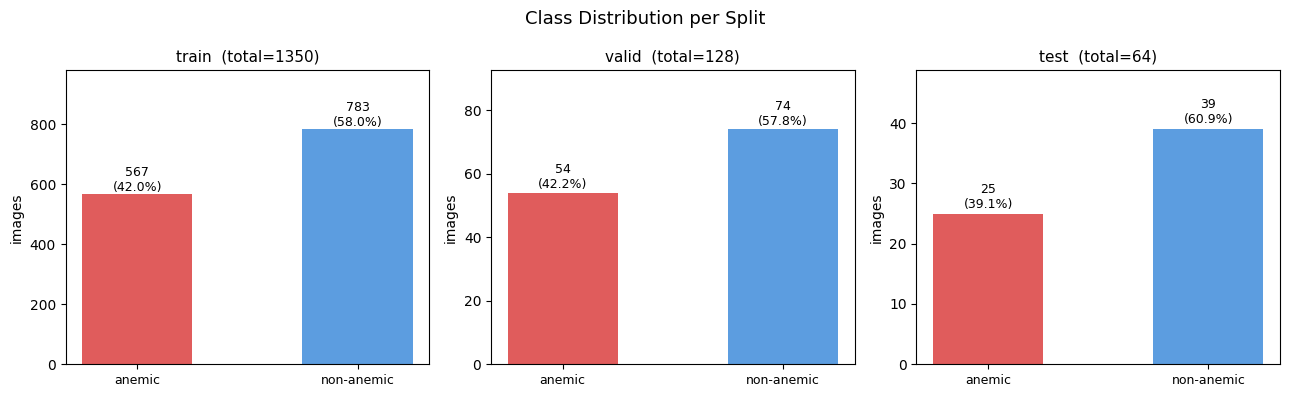

Saved: class_distribution.png


In [6]:
# ── Distribution bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = {'anemic': '#e05c5c', 'non-anemic': '#5c9de0'}

for ax, split in zip(axes, SPLITS):
    vals  = [counts[split][c] for c in CLASSES]
    bars  = ax.bar(CLASSES, vals, color=[colors[c] for c in CLASSES], width=0.5)
    total = sum(vals)
    for bar, v in zip(bars, vals):
        pct = f"{v/total*100:.1f}%" if total > 0 else "0%"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v}\n({pct})", ha='center', va='bottom', fontsize=9)
    ax.set_title(f"{split}  (total={total})", fontsize=11)
    ax.set_ylim(0, max(vals) * 1.25 if vals else 10)
    ax.set_ylabel('images')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Class Distribution per Split', fontsize=13)
plt.tight_layout()
plt.savefig(WORK_DIR / 'class_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

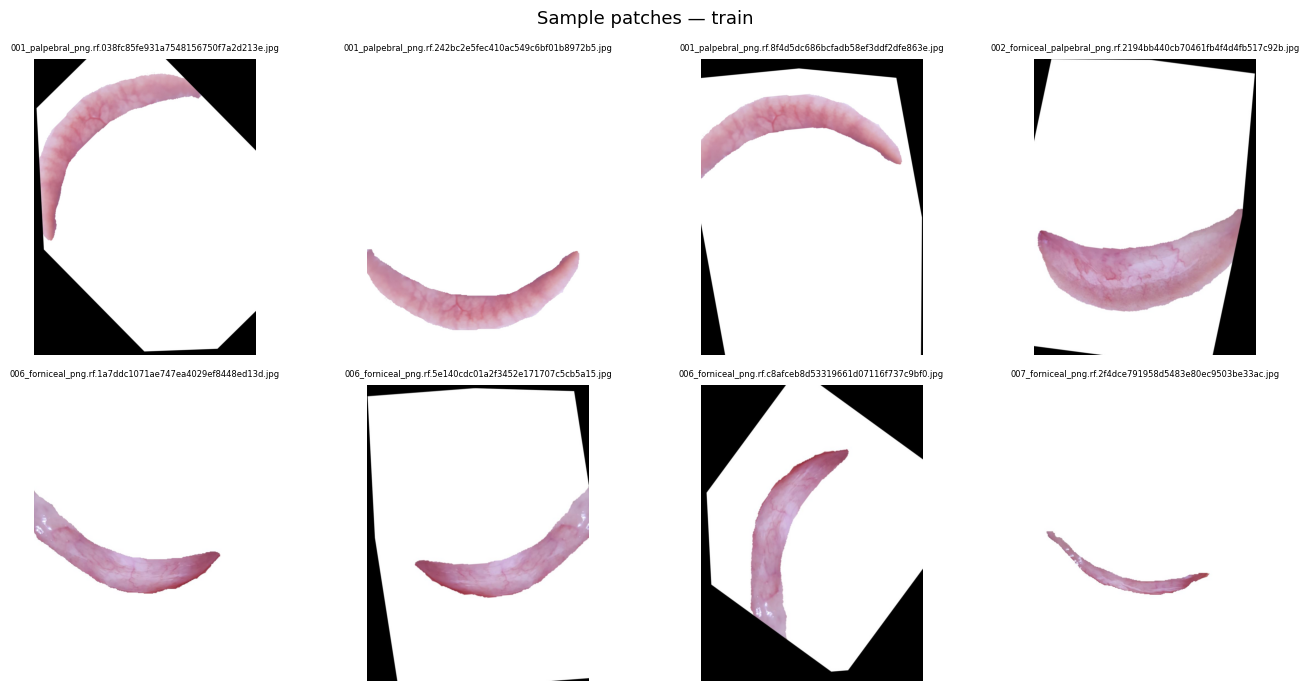

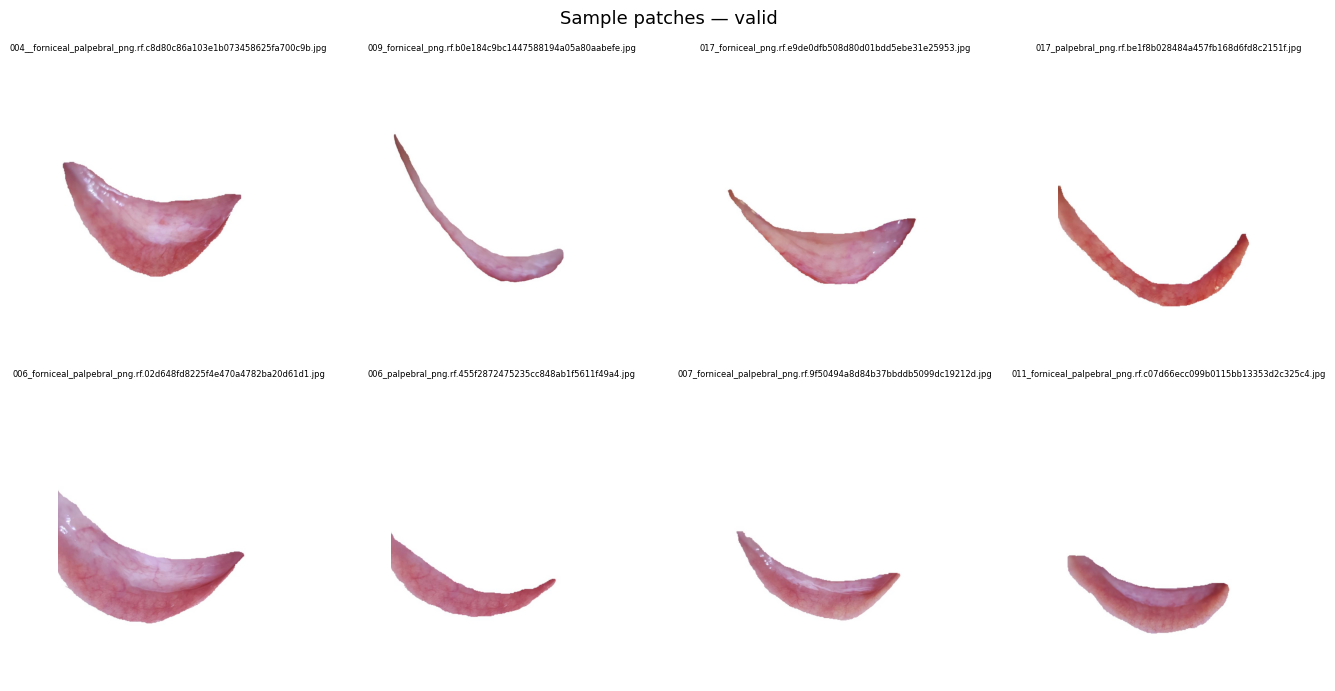

In [7]:
# ── Visualise sample patches per class ───────────────────────────────────────
def visualise_class_samples(split='train', n_per_class=4):
    fig, axes = plt.subplots(len(CLASSES), n_per_class,
                             figsize=(3.5 * n_per_class, 3.5 * len(CLASSES)))

    for row, cls in enumerate(CLASSES):
        cls_dir = DATASET_ROOT / split / cls
        imgs    = sorted(cls_dir.glob('*.jpg'))[:n_per_class] \
                  if cls_dir.exists() else []
        if not imgs:
            imgs = sorted(cls_dir.glob('*.png'))[:n_per_class] \
                   if cls_dir.exists() else []

        for col in range(n_per_class):
            ax = axes[row][col]
            if col < len(imgs):
                img = np.array(Image.open(imgs[col]).convert('RGB'))
                ax.imshow(img)
                ax.set_title(imgs[col].name, fontsize=6)
            else:
                ax.set_visible(False)
            ax.axis('off')

        axes[row][0].set_ylabel(f"class {CLASSES.index(cls)} — {cls}",
                                fontsize=10, rotation=90, labelpad=4)

    plt.suptitle(f'Sample patches — {split}', fontsize=13)
    plt.tight_layout()
    plt.savefig(WORK_DIR / f'samples_{split}.png', dpi=120, bbox_inches='tight')
    plt.show()

visualise_class_samples('train', n_per_class=4)
visualise_class_samples('valid', n_per_class=4)

In [8]:
# ── Verify image sizes (all should be similar for conjunctiva patches) ────────
print("Image size sample (train/anemic, first 5):")
for p in sorted((DATASET_ROOT / 'train' / 'anemic').glob('*.jpg'))[:5]:
    w, h = Image.open(p).size
    print(f"  {p.name:40s}  {w}×{h}")

Image size sample (train/anemic, first 5):
  001_palpebral_png.rf.038fc85fe931a7548156750f7a2d213e.jpg  1535×2047
  001_palpebral_png.rf.242bc2e5fec410ac549c6bf01b8972b5.jpg  1535×2047
  001_palpebral_png.rf.8f4d5dc686bcfadb58ef3ddf2dfe863e.jpg  1535×2047
  002_forniceal_palpebral_png.rf.2194bb440cb70461fb4f4d4fb517c92b.jpg  800×1067
  002_forniceal_palpebral_png.rf.ccaea716778a3c5d06bc752b682fa08c.jpg  800×1067


## 4. Training YOLO26s-cls

YOLO classification trainer expects the dataset root to contain  
`train/class_name/`, `val/class_name/` subdirectories.  
The Roboflow download uses `valid/` — we pass the root and let YOLO find splits automatically.

In [9]:
# ── Rename valid → val if YOLO complains ────────────────────────────────────
# YOLO cls trainer accepts both 'val' and 'valid', but let's ensure 'valid'
# is present. If only 'val' exists after rename issues, create a symlink.
valid_dir = DATASET_ROOT / 'valid'
val_dir   = DATASET_ROOT / 'val'

if valid_dir.exists() and not val_dir.exists():
    val_dir.symlink_to(valid_dir)
    print(f"Symlinked: valid → val")
else:
    print(f"val/valid dirs: val={val_dir.exists()}  valid={valid_dir.exists()}")

Symlinked: valid → val


In [10]:
from ultralytics import YOLO

cls_model = YOLO('yolo26s-cls.pt')
cls_model.info()

YOLO26s-cls summary: 120 layers, 6,724,008 parameters, 0 gradients, 13.2 GFLOPs


(120, 6724008, 0, 13.158604799999999)

In [11]:
# ── Train ─────────────────────────────────────────────────────────────────────
# data = path to dataset root containing train/ val/ test/
# YOLO cls trainer auto-discovers class names from subdirectory names (sorted).
# anemic=0, non-anemic=1  (alphabetical)

cls_results = cls_model.train(
    data       = str(DATASET_ROOT),
    imgsz      = IMG_SIZE,
    epochs     = EPOCHS,
    batch      = BATCH_SIZE,
    device     = DEVICE,
    optimizer  = 'SGD',
    patience   = PATIENCE,
    amp        = True,
    project    = str(WORK_DIR / 'runs' / 'classify'),
    name       = RUN_NAME,
    exist_ok   = False,
    verbose    = True,
    save       = True,
    save_period= 20,
    # Default YOLO augmentation — no customisation
)

print("\n✅ Training complete")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/anemia-classification-2, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=448, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train

## 5. Evaluation — Metrics, Confusion Matrix, Per-class Report

In [12]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
best_weights = WORK_DIR / 'runs' / 'classify' / RUN_NAME / 'weights' / 'best.pt'
assert best_weights.exists(), f"best.pt not found: {best_weights}"
print(f"Best weights: {best_weights}  ({best_weights.stat().st_size/1e6:.1f} MB)")

best_cls = YOLO(str(best_weights))

Best weights: /kaggle/working/runs/classify/train-anemia26s-cls/weights/best.pt  (11.0 MB)


In [13]:
# ── Val metrics ───────────────────────────────────────────────────────────────
val_metrics = best_cls.val(
    data    = str(DATASET_ROOT),
    imgsz   = IMG_SIZE,
    split   = 'val',
    device  = DEVICE,
    verbose = True,
)
print(f"\n── Val ──")
print(f"  Top-1 accuracy : {val_metrics.top1:.4f}")
print(f"  Top-5 accuracy : {val_metrics.top5:.4f}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
YOLO26s-cls summary (fused): 47 layers, 5,436,690 parameters, 0 gradients, 12.0 GFLOPs
train: /kaggle/working/anemia-classification-2/train... found 1350 images in 2 classes ✅ 
val: /kaggle/working/anemia-classification-2/val... found 128 images in 2 classes ✅ 
test: /kaggle/working/anemia-classification-2/test... found 64 images in 2 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 918.4±270.6 MB/s, size: 23.8 KB)
val: Scanning /kaggle/working/anemia-classification-2/val... 128 images, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 26.8Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8/8 9.8it/s 0.8s0.1s
                   all      0.906          1
Speed: 0.5ms preprocess, 4.3ms inference, 0.1ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val

── Val ──
  To

In [14]:
# ── Test metrics ──────────────────────────────────────────────────────────────
test_metrics = best_cls.val(
    data    = str(DATASET_ROOT),
    imgsz   = IMG_SIZE,
    split   = 'test',
    device  = DEVICE,
    verbose = True,
)
print(f"\n── Test ──")
print(f"  Top-1 accuracy : {test_metrics.top1:.4f}")
print(f"  Top-5 accuracy : {test_metrics.top5:.4f}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
train: /kaggle/working/anemia-classification-2/train... found 1350 images in 2 classes ✅ 
val: /kaggle/working/anemia-classification-2/val... found 128 images in 2 classes ✅ 
test: /kaggle/working/anemia-classification-2/test... found 64 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 797.1±221.2 MB/s, size: 22.5 KB)
test: Scanning /kaggle/working/anemia-classification-2/test... 64 images, 0 corrupt: 100% ━━━━━━━━━━━━ 64/64 2.7Kit/s 0.0s
test: New cache created: /kaggle/working/anemia-classification-2/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 4/4 4.6it/s 0.9s0.5s
                   all      0.875          1
Speed: 0.3ms preprocess, 2.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val-2

── Test ──
  Top-1 accur

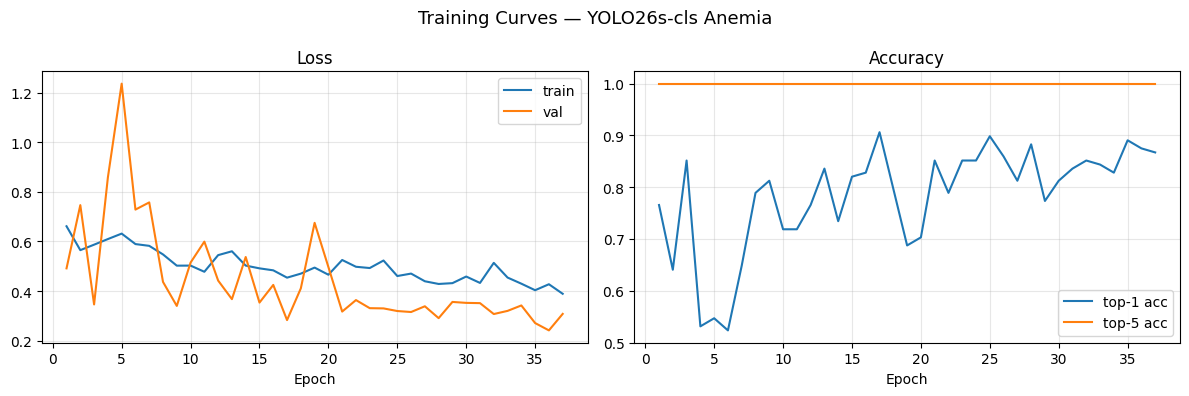

Saved: training_curves.png


In [15]:
# ── Training curves ───────────────────────────────────────────────────────────
import pandas as pd

results_csv = WORK_DIR / 'runs' / 'classify' / RUN_NAME / 'results.csv'
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    for col, lbl in [('train/loss', 'train'), ('val/loss', 'val')]:
        if col in df.columns:
            axes[0].plot(df['epoch'], df[col], label=lbl)
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_xlabel('Epoch')

    # Accuracy
    for col, lbl in [('metrics/accuracy_top1', 'top-1 acc'),
                     ('metrics/accuracy_top5', 'top-5 acc')]:
        if col in df.columns:
            axes[1].plot(df['epoch'], df[col], label=lbl)
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_xlabel('Epoch')

    plt.suptitle('Training Curves — YOLO26s-cls Anemia', fontsize=13)
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_curves.png")
else:
    print(f"results.csv not found at {results_csv}")

In [16]:
# ── Confusion matrix + per-class report (test set) ────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# ── Run predictions on entire test set ───────────────────────────────────────
y_true, y_pred = [], []

for cls_idx, cls_name in enumerate(CLASSES):
    cls_dir  = DATASET_ROOT / 'test' / cls_name
    img_list = sorted(cls_dir.glob('*.jpg')) + sorted(cls_dir.glob('*.png'))

    if not img_list:
        print(f"⚠️  No test images for class '{cls_name}'")
        continue

    preds = best_cls.predict(
        source  = img_list,
        imgsz   = IMG_SIZE,
        device  = DEVICE,
        verbose = False,
    )

    for r in preds:
        pred_cls = int(r.probs.top1)
        y_true.append(cls_idx)
        y_pred.append(pred_cls)

print(f"Test samples predicted: {len(y_true)}")
print(f"Ground truth dist : {Counter(y_true)}")
print(f"Prediction dist   : {Counter(y_pred)}")

Test samples predicted: 64
Ground truth dist : Counter({1: 39, 0: 25})
Prediction dist   : Counter({1: 37, 0: 27})


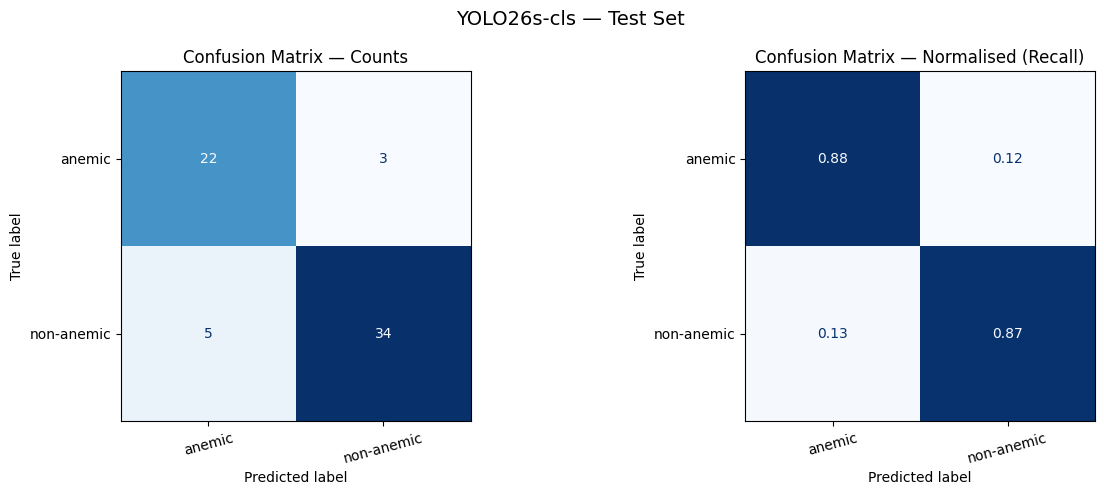

Saved: confusion_matrix.png


In [17]:
# ── Confusion matrix plot ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASSES))))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
disp_counts = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp_counts.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Counts', fontsize=12)
axes[0].tick_params(axis='x', labelrotation=15)

# Normalised (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(np.round(cm_norm, 3), display_labels=CLASSES)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Normalised (Recall)', fontsize=12)
axes[1].tick_params(axis='x', labelrotation=15)

plt.suptitle('YOLO26s-cls — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig(WORK_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

In [18]:
# ── Per-class classification report ──────────────────────────────────────────
report = classification_report(
    y_true, y_pred,
    target_names = CLASSES,
    digits       = 4
)
print("── Per-class Report (Test Set) ──")
print(report)

# Save as txt
report_path = WORK_DIR / 'classification_report.txt'
with open(report_path, 'w') as f:
    f.write(f"YOLO26s-cls — Anemia Classification\n")
    f.write(f"Test Set\n")
    f.write("=" * 50 + "\n")
    f.write(report)
print(f"Saved: {report_path}")

── Per-class Report (Test Set) ──
              precision    recall  f1-score   support

      anemic     0.8148    0.8800    0.8462        25
  non-anemic     0.9189    0.8718    0.8947        39

    accuracy                         0.8750        64
   macro avg     0.8669    0.8759    0.8704        64
weighted avg     0.8783    0.8750    0.8758        64

Saved: /kaggle/working/classification_report.txt


Total misclassified: 8 / 64


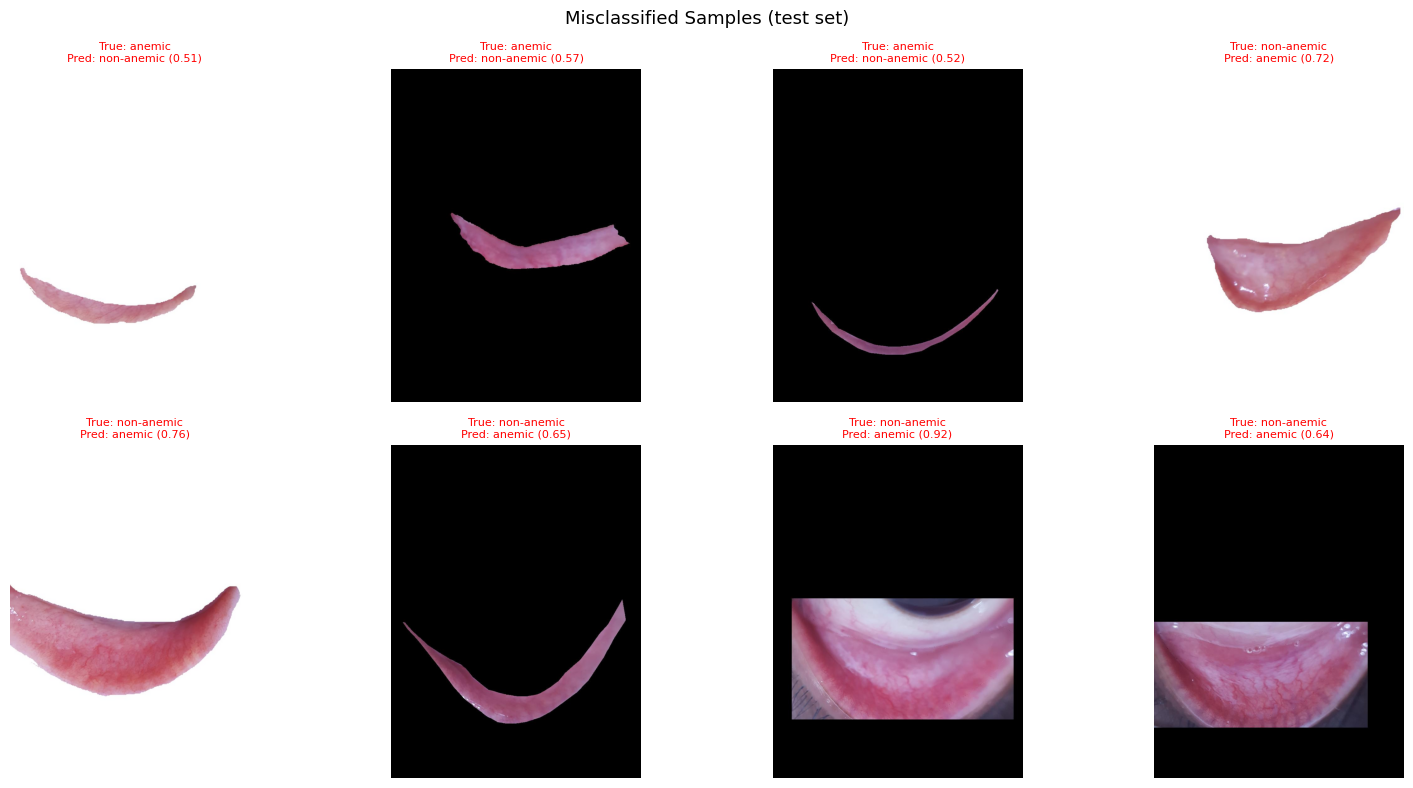

Saved: misclassified.png


In [19]:
# ── Visualise misclassified samples ──────────────────────────────────────────
# Collect up to 8 misclassified images for inspection
misclassified = []
for cls_idx, cls_name in enumerate(CLASSES):
    cls_dir  = DATASET_ROOT / 'test' / cls_name
    img_list = sorted(cls_dir.glob('*.jpg')) + sorted(cls_dir.glob('*.png'))
    if not img_list: continue

    preds = best_cls.predict(
        source=img_list, imgsz=IMG_SIZE, device=DEVICE, verbose=False)

    for img_path, r in zip(img_list, preds):
        pred_idx = int(r.probs.top1)
        conf     = float(r.probs.top1conf)
        if pred_idx != cls_idx:
            misclassified.append({
                'path'      : img_path,
                'true_cls'  : cls_name,
                'pred_cls'  : CLASSES[pred_idx],
                'conf'      : conf,
            })

print(f"Total misclassified: {len(misclassified)} / {len(y_true)}")

if misclassified:
    show = misclassified[:8]
    cols = 4
    rows = (len(show) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).flatten()

    for ax, item in zip(axes, show):
        img = np.array(Image.open(item['path']).convert('RGB'))
        ax.imshow(img)
        ax.set_title(
            f"True: {item['true_cls']}\nPred: {item['pred_cls']} ({item['conf']:.2f})",
            fontsize=8, color='red')
        ax.axis('off')

    for ax in axes[len(show):]: ax.set_visible(False)

    plt.suptitle('Misclassified Samples (test set)', fontsize=13)
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'misclassified.png', dpi=130, bbox_inches='tight')
    plt.show()
    print("Saved: misclassified.png")
else:
    print("🎉 No misclassifications on test set!")

## 6. Export

Same strategy as segmentation model:
- **TFLite FP16** — primary Android (GPU delegate, consistent with seg model)
- **ONNX FP32** — parity baseline & debug

> ExecuTorch is skipped for the same reason as the seg model:  
> `KeyError: 'feats'` in Ultralytics 8.4.x + YOLO26 `torch.export` path.

### 6a. ONNX FP32 (parity baseline)

In [20]:
onnx_path = best_cls.export(
    format   = 'onnx',
    imgsz    = IMG_SIZE,
    opset    = 18,
    dynamic  = True,
    half     = False,
    simplify = True,
    device   = 'cpu',
)

onnx_dst = EXPORT_DIR / 'yolo26s_cls_fp32.onnx'
shutil.copy(onnx_path, onnx_dst)
print(f"✅ ONNX FP32 → {onnx_dst}  ({onnx_dst.stat().st_size/1e6:.1f} MB)")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/classify/train-anemia26s-cls/weights/best.pt' with input shape (1, 3, 448, 448) BCHW and output shape(s) (1, 2) (10.5 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.71'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 202ms
Prepared 1 package in 62ms
Installed 1 package in 11ms
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 18...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 2.0s, saved as '/kaggle/working/runs/classify/train-anemia26s-cls/weights/best.onnx' (20.8 MB)

Export complete (2.1s)
Re

### 6b. TFLite FP16 (primary Android)

In [21]:
try:
    import tensorflow as tf
    print(f"TensorFlow {tf.__version__} already installed")
except ImportError:
    print("Installing tensorflow...")
    !pip install tensorflow --quiet

tflite_path = best_cls.export(
    format = 'tflite',
    imgsz  = IMG_SIZE,
    half   = True,   # FP16 — GPU delegate path in AnedetApp
    int8   = False,
    device = 'cpu',
)

tflite_dst = EXPORT_DIR / 'yolo26s_cls_fp16.tflite'
shutil.copy(tflite_path, tflite_dst)
print(f"\n✅ TFLite FP16 → {tflite_dst}  ({tflite_dst.stat().st_size/1e6:.1f} MB)")

E0000 00:00:1780046281.300716      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780046281.354446      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780046281.799876      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780046281.799901      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780046281.799904      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780046281.799906      58 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow 2.19.0 already installed
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/classify/train-anemia26s-cls/weights/best.pt' with input shape (1, 3, 448, 448) BCHW and output shape(s) (1, 2) (10.5 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 0.9s, saved as '/kaggle/working/runs/classify/train-anemia26s-cls/weights/best.onnx' (20.8 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 14 packages in 2.52s
Prepared 6 packages in 2.63s
Installed 6 packages in 93ms
 + ai-edge-litert==2.1.5
 + backports-strenum==1.3.1
 + onnx-graphsurgeon==0.6.1
 + onnx2tf==1.28.8
 + onnxruntime-gpu==1.26.0
 + sng4onnx==2.0.1

requirements: AutoUpdate succ

I0000 00:00:1780046300.531425      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12269 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780046300.536551      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1780046303.574910      58 cuda_dnn.cc:529] Loaded cuDNN version 91002


Saved artifact at '/kaggle/working/runs/classify/train-anemia26s-cls/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 448, 448, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 2), dtype=tf.float32, name=None)
Captures:
  132464431335376: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  132464431333648: TensorSpec(shape=(3, 3, 3, 32), dtype=tf.float32, name=None)
  132464431333840: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  132464431340176: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  132465978913040: TensorSpec(shape=(3, 3, 32, 64), dtype=tf.float32, name=None)
  132464431338256: TensorSpec(shape=(64,), dtype=tf.float32, name=None)
  132464431340368: TensorSpec(shape=(1, 1, 64, 64), dtype=tf.float32, name=None)
  132464431340560: TensorSpec(shape=(64,), dtype=tf.float32, name=None)
  132464431341520: TensorSpec(shape=(4,), dtype=tf.int64, 

I0000 00:00:1780046306.287533      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1780046306.287709      58 single_machine.cc:374] Starting new session
I0000 00:00:1780046306.301293      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12269 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780046306.302771      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
W0000 00:00:1780046307.054110      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780046307.054140      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1780046307.902964      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1780046307.903

TensorFlow SavedModel: export success ✅ 17.2s, saved as '/kaggle/working/runs/classify/train-anemia26s-cls/weights/best_saved_model' (52.0 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/kaggle/working/runs/classify/train-anemia26s-cls/weights/best_saved_model/best_float16.tflite' (10.4 MB)

Export complete (17.4s)
Results saved to /kaggle/working/runs/classify/train-anemia26s-cls/weights/best_saved_model/best_float16.tflite
Predict:         yolo predict task=classify model=/kaggle/working/runs/classify/train-anemia26s-cls/weights/best_saved_model/best_float16.tflite imgsz=448 half
Validate:        yolo val task=classify model=/kaggle/working/runs/classify/train-anemia26s-cls/weights/best_saved_model/best_float16.tflite imgsz=448 data=/kaggle/working/anemia-classification-2 half 
Visualize:       https://netron.app

✅ TFLite FP16 → /kaggle/working/exports/anemia-cls-yolo26s/yolo26s_cls_fp16.tflite  (10.9 MB)


### 6c. metadata.yaml

In [22]:
metadata = {
    'model'            : 'yolo26s-cls',
    'task'             : 'classify',
    'imgsz'            : IMG_SIZE,
    'nc'               : len(CLASSES),
    'names'            : {i: c for i, c in enumerate(CLASSES)},
    'primary_format'   : 'tflite',
    'precision'        : 'fp16',
    'android_delegate' : 'GPU (CompatibilityList + bestOptionsForThisDevice)',
    'class_order'      : 'alphabetical — anemic=0, non-anemic=1',
    'anedetapp_mapping': '0=Anemia, 1=Non-Anemia',
    'input_note'       : 'Pre-cropped conjunctiva patch from segmentation model',
    'val_top1'         : round(float(val_metrics.top1),  4),
    'val_top5'         : round(float(val_metrics.top5),  4),
    'test_top1'        : round(float(test_metrics.top1), 4),
    'test_top5'        : round(float(test_metrics.top5), 4),
}

meta_path = EXPORT_DIR / 'metadata.yaml'
with open(meta_path, 'w') as f:
    yaml.dump(metadata, f, default_flow_style=False, sort_keys=False)

print(f"Metadata → {meta_path}")
print()
print(open(meta_path).read())

Metadata → /kaggle/working/exports/anemia-cls-yolo26s/metadata.yaml

model: yolo26s-cls
task: classify
imgsz: 448
nc: 2
names:
  0: anemic
  1: non-anemic
primary_format: tflite
precision: fp16
android_delegate: GPU (CompatibilityList + bestOptionsForThisDevice)
class_order: "alphabetical \u2014 anemic=0, non-anemic=1"
anedetapp_mapping: 0=Anemia, 1=Non-Anemia
input_note: Pre-cropped conjunctiva patch from segmentation model
val_top1: 0.9062
val_top5: 1.0
test_top1: 0.875
test_top5: 1.0



## 7. Parity Testing — PyTorch vs ONNX

In [27]:
import onnxruntime as ort
print(f"ONNXRuntime: {ort.__version__}")

# Tambahkan argumen task='classify' secara eksplisit di sini
onnx_cls = YOLO(str(onnx_dst), task='classify') 

onnx_val = onnx_cls.val(
    data    = str(DATASET_ROOT),
    imgsz   = IMG_SIZE,
    split   = 'val',
    device  = 'cpu',
    verbose = False,
)

pt_acc   = float(val_metrics.top1)
onnx_acc = float(onnx_val.top1)
delta    = abs(pt_acc - onnx_acc)
TOLS     = 0.01   # ≤ 1% tolerance for classification

print(f"\n── Parity Report (Val Top-1 Accuracy) ──")
print(f"  PyTorch .pt  : {pt_acc:.4f}")
print(f"  ONNX FP32    : {onnx_acc:.4f}")
print(f"  Δ            : {delta:.4f}")
print(f"  Tolerance    : ≤ {TOLS*100:.1f}%")
if delta <= TOLS:
    print("  ✅ PASS")
else:
    print("  ⚠️  FAIL — inspect export (opset, simplify)")

ONNXRuntime: 1.26.0
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Loading /kaggle/working/exports/anemia-cls-yolo26s/yolo26s_cls_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider
train: /kaggle/working/anemia-classification-2/train... found 1350 images in 2 classes ✅ 
val: /kaggle/working/anemia-classification-2/val... found 128 images in 2 classes ✅ 
test: /kaggle/working/anemia-classification-2/test... found 64 images in 2 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 860.4±283.7 MB/s, size: 23.8 KB)
val: Scanning /kaggle/working/anemia-classification-2/val... 128 images, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 19.9Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8/8 1.2it/s 6.7s0.9ss
                   all      0.906          1
Speed: 0.0ms preprocess, 34.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val-4

──

Loading /kaggle/working/exports/anemia-cls-yolo26s/yolo26s_cls_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider


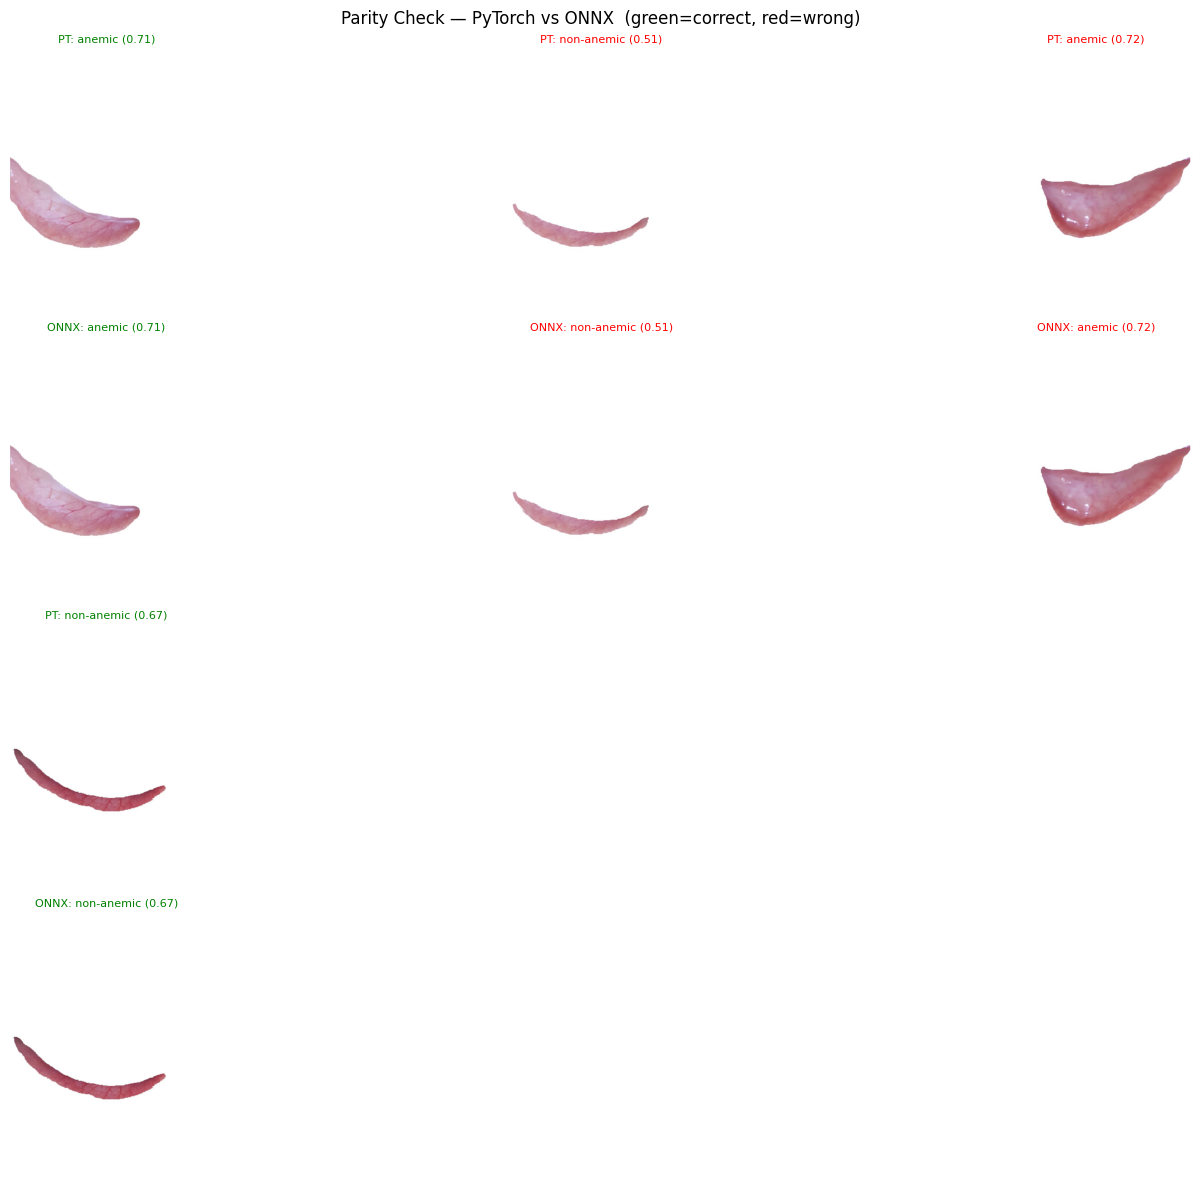

Saved: parity_visual.png


In [28]:
# ── Side-by-side prediction on same test samples ──────────────────────────────
sample_imgs = []
for cls in CLASSES:
    imgs = sorted((DATASET_ROOT / 'test' / cls).glob('*.jpg'))[:2]
    if not imgs:
        imgs = sorted((DATASET_ROOT / 'test' / cls).glob('*.png'))[:2]
    sample_imgs.extend(imgs)

sample_imgs = sample_imgs[:6]

pt_preds   = best_cls.predict(sample_imgs,   imgsz=IMG_SIZE, device=DEVICE, verbose=False)
onnx_preds = onnx_cls.predict(sample_imgs,   imgsz=IMG_SIZE, device='cpu',  verbose=False)

cols = 3
rows = (len(sample_imgs) + cols - 1) // cols
fig, axes = plt.subplots(rows * 2, cols, figsize=(5*cols, 3*rows*2))
axes = np.array(axes).reshape(rows * 2, cols)

for i, (img_path, pt_r, onnx_r) in enumerate(zip(sample_imgs, pt_preds, onnx_preds)):
    row, col = (i // cols) * 2, i % cols
    img = np.array(Image.open(img_path).convert('RGB'))

    pt_cls   = CLASSES[int(pt_r.probs.top1)]
    pt_conf  = float(pt_r.probs.top1conf)
    onnx_cls_name = CLASSES[int(onnx_r.probs.top1)]
    onnx_conf     = float(onnx_r.probs.top1conf)

    axes[row][col].imshow(img)
    axes[row][col].set_title(
        f"PT: {pt_cls} ({pt_conf:.2f})", fontsize=8,
        color='green' if pt_cls == Path(img_path).parent.name else 'red')
    axes[row][col].axis('off')

    axes[row+1][col].imshow(img)
    axes[row+1][col].set_title(
        f"ONNX: {onnx_cls_name} ({onnx_conf:.2f})", fontsize=8,
        color='green' if onnx_cls_name == Path(img_path).parent.name else 'red')
    axes[row+1][col].axis('off')

# Hide unused subplots
for i in range(len(sample_imgs), rows * cols):
    row, col = (i // cols) * 2, i % cols
    axes[row][col].set_visible(False)
    axes[row+1][col].set_visible(False)

plt.suptitle('Parity Check — PyTorch vs ONNX  (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.savefig(WORK_DIR / 'parity_visual.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: parity_visual.png")

## 8. Artifact Summary

In [29]:
print("=" * 68)
print("  TRAINING COMPLETE — Artifact Summary")
print("=" * 68)

artifacts = [
    ('Best weights (.pt)',        best_weights),
    ('TFLite FP16 (.tflite)',     tflite_dst),
    ('ONNX FP32 (.onnx)',         onnx_dst),
    ('Metadata (.yaml)',          meta_path),
    ('Class distribution',        WORK_DIR / 'class_distribution.png'),
    ('Training curves',           WORK_DIR / 'training_curves.png'),
    ('Confusion matrix',          WORK_DIR / 'confusion_matrix.png'),
    ('Classification report',     WORK_DIR / 'classification_report.txt'),
    ('Misclassified samples',     WORK_DIR / 'misclassified.png'),
    ('Parity visual',             WORK_DIR / 'parity_visual.png'),
]

for label, path in artifacts:
    path = Path(path)
    if path.exists():
        mb = path.stat().st_size / 1e6
        print(f"  ✅  {label:<28}  {path.name:<46}  {mb:6.2f} MB")
    else:
        print(f"  ⚠️   {label:<28}  NOT FOUND — {path}")

print()
print("── Metrics ──")
print(f"  Val  Top-1 acc : {val_metrics.top1:.4f}")
print(f"  Test Top-1 acc : {test_metrics.top1:.4f}")
print()
print("── Class mapping (AnedetApp) ──")
for i, cls in enumerate(CLASSES):
    print(f"  {i} = {cls}")
print()
print("── Android integration (AnedetApp) ──")
print("  1. Copy yolo26s_cls_fp16.tflite → app/src/main/assets/models/")
print("  2. Update classifier model path in AnedetApp TFLite loader")
print("  3. Input: conjunctiva crop from yolo26n_seg_fp16.tflite output")
print("  4. Output: softmax → index 0=Anemia, 1=Non-Anemia")
print("=" * 68)

  TRAINING COMPLETE — Artifact Summary
  ✅  Best weights (.pt)            best.pt                                          11.03 MB
  ✅  TFLite FP16 (.tflite)         yolo26s_cls_fp16.tflite                          10.93 MB
  ✅  ONNX FP32 (.onnx)             yolo26s_cls_fp32.onnx                            21.84 MB
  ✅  Metadata (.yaml)              metadata.yaml                                     0.00 MB
  ✅  Class distribution            class_distribution.png                            0.05 MB
  ✅  Training curves               training_curves.png                               0.10 MB
  ✅  Confusion matrix              confusion_matrix.png                              0.05 MB
  ✅  Classification report         classification_report.txt                         0.00 MB
  ✅  Misclassified samples         misclassified.png                                 0.31 MB
  ✅  Parity visual                 parity_visual.png                                 0.17 MB

── Metrics ──
  Val  Top-1 acc